# StanLyric — BM25 Lyric Fragment Song Identifier

This notebook is the first offline development workflow for **StanLyric**.

Goal: given a lyric fragment, retrieve the most likely songs using BM25, inspect matched snippets, and evaluate retrieval with Hit@k, MRR@10, and NDCG@10.


## 0. Setup
Run this once in Colab or a local notebook from the repository root.

In [1]:
import sys
import pandas as pd
from pathlib import Path

# Point imports at the live src/ tree, without requiring `pip install -e .`.
def find_repo_root(start=Path.cwd()):
    for path in (start, *start.parents):
        if (path / "src" / "stanlyric").is_dir():
            return path
    raise RuntimeError("Could not find repo root containing src/stanlyric")


REPO_ROOT = find_repo_root()
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

%load_ext autoreload
%autoreload 2

from stanlyric.hf_download import rank_lyric_files, candidates_to_dataframe, auto_download_best_candidate
from stanlyric.data import load_raw_dataset, prepare_corpus, save_corpus, CorpusConfig
from stanlyric.search import StanLyricSearchEngine
from stanlyric.evaluation import RetrievalEvaluator, EvalConfig
from stanlyric.visualization import plot_top_scores, plot_metric_summary, plot_rank_distribution


/Users/dhillo/anaconda3/envs/garage/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Inspect Hugging Face files without downloading the full dataset
The dataset is large, so we rank small lyrics/metadata candidates and avoid MIDI/audio/huge archives by default.

In [2]:
candidates = rank_lyric_files(max_size_mb=900)
candidate_df = candidates_to_dataframe(candidates)
candidate_df.head(20)

,path,size_mb,score,reason
0,Lyrics_MIDI_Dataset_Processed_Corpus_CC_BY_NC_...,67.61,23.0,"lyrics, lyric, corpus"


## 2. Download one selected lyrics/metadata file
By default this downloads the top-ranked candidate. If you see a better file in the table above, pass its `path` to `download_file` or run the script with `--filename`.

In [3]:
# Auto-download the top candidate. Change rank=1/2/etc. if candidate_df suggests a better file.
raw_path, candidates = auto_download_best_candidate(output_dir="data/raw", max_size_mb=900, rank=0)
raw_path

/Users/dhillo/anaconda3/envs/garage/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


PosixPath('data/raw/Lyrics_MIDI_Dataset_Processed_Corpus_CC_BY_NC_SA.pickle')

## 3. Prepare StanLyric corpus
This normalizes arbitrary dataset columns into: `doc_id`, `title`, `artist`, `lyrics`, `source`, `lyrics_char_len`.

In [4]:
raw_df = load_raw_dataset(raw_path)
print(raw_df.shape)
raw_df.head()

(2, 47537)


,Meet Me Halfway --- Black Eyed Peas --- fc3579d356472017ece11406621e642e,Lay Your Hands --- Simon Webbe --- 3ae97ab7c8191c3e345564d4eae8a8dc,Communion And The Oracle --- Unknown --- 6cb3661c80d04e1d7029e22cb24eafef,Acid --- Unknown --- 98c34d41cb7e328ef63cd1b0283d406e,Intermezzo --- Unknown --- acbd0a4fd6f99c3fcebc4b5ccfb877ae,Again And Again --- Status Quo --- 67c4f038beeaf514d74e6e64bd199cb7,Say Say Say --- Paul Mccartney Michael Jackson --- 9bb8d04a79f6466b166248b267fa8dca,Mary Jane --- Alanis Morissette --- 1a1c96f2bfde217b9624dcbc46a8866d,Father Of Mine (Re-Recorded) --- Everclear --- e044811f7e7a75707313c99048c36490,Hello --- Adele --- b16df5e743714904b3d7376a8f6793d5,...,Give Thanks --- J Boog --- 8351e8f02ae141b9279261945f582f96,Lullaby --- Creed --- 6bea795d880e3837f940f32da4a5e01c,It May Be Winter Outside (But In My Heart It'S Spring) --- Love Unlimited --- 5f70d991f4bbbd7f10ae6891a54d77b7,Name [New Version] --- The Goo Goo Dolls --- cd7d7b8410d5eabc00c3a4fbf73801ef,Vibeology --- Paula Abdul --- 6e6a13b0dab2d688b6813fd4b432db26,I Saw The Light --- Todd Rundgren --- 0b06f98fd6667aee1d6fe7b3ec297a0e,I Really Want You - Radio Edit [Radio Edit] --- James Blunt --- 1f45aeb66d0b13cf0d9a2c50fd69a966,Arrivederci Roma --- Dean Martin --- 0dadd0a207aed9580d168ff8f476670a,Jeans --- Unknown --- a36f2f665351fd11c325927d5a0e9c21,My Love --- Paul Mccartney --- 414a35d85c3cb2c2846c97876c9eff35
keywords,"[borderline, galaxy, wish, universe, uptown, t...","[chorus, burden, survive, suffering, baby, lif...","[prayer, earthly, balance, tranquillity, sky, ...","[depression, demon, demise, fate, darkest, bur...","[emptiness, darkness, soul, shadow, illusion, ...","[rhythm, rock, rockin, guitar, music, clock, r...","[mccartney, chorus, paul, verse, jackson, mich...","[mary, jane, line, tear, car, bruise, baby, wo...","[daddy, father, child, grown, block, sky, boy,...","[healing, sorry, hello, mile, heart, time, tow...",...,"[lyric, jah, road, temptation, outlaw, yo, spi...","[love, rest, sleep, peaceful, dream, life, hop...","[warm, winter, snow, cold, temperature, baby, ...","[orphan, song, lonely, sad, past, life, scar, ...","[vibeology, vibe, vibeolistic, funky, groove, ...","[soul, light, sight, feeling, girl, eye, night...","[prophet, beggar, cleric, fate, bended, luck, ...","[roma, rome, arriverderci, wedding, city, love...","[dark, lost, blind, misunderstood, shoe, seam,...","[love, goodbye, heart, whoa, cupboard, hand, g..."
lyrics,"Ooh, I can't go any further than this\nOoh, I ...",Sometimes life can be a burden\nTryna stay one...,"All we know, now has come undone\nBalance lost...",How can I expect to read between the lines\n\n...,I woke up with a feeling of emptiness inside\n...,Once upon a time not so very long ago\nThere w...,43 ContributorsSay Say Say Lyrics[Verse 1: Pau...,"What's the matter Mary Jane, had a hard day?\n...",Father of mine\nTell me where have you been?\n...,"Hello, it's me\nI was wondering if after all t...",...,true which part me come from\nme coulda been a...,Hush my love now don't you cry\nEverything wil...,When the temperature dips\nI miss my baby's ar...,And even though the moment passed me by\nI sti...,"It, it's you\nIt, it's, it's you (ooh, yeah)\n...",It was late last night\nI was feeling somethin...,Many prophets preach on bended knee\nMany cler...,"Arriverderci, Roma\nGoodbye, goodbye to Rome\n...",Maybe I would come home with eyes\nLike you ne...,And when I go away\nI know my heart can stay w...


In [5]:
corpus = prepare_corpus(
    raw_df,
    CorpusConfig(min_lyric_chars=80, max_docs=None, deduplicate_lyrics=True),
)
save_corpus(corpus, "data/processed/corpus.parquet")
print(corpus.shape)
corpus[["doc_id", "title", "artist", "lyrics_char_len"]].head()

(44480, 6)


,doc_id,title,artist,lyrics_char_len
0,song_0000000,Meet Me Halfway,Black Eyed Peas,2269
1,song_0000001,Lay Your Hands,Simon Webbe,1261
2,song_0000002,Communion And The Oracle,Unknown,1402
3,song_0000003,Acid,Unknown,706
4,song_0000004,Intermezzo,Unknown,1025


## 4. Build BM25 index

In [6]:
engine = StanLyricSearchEngine(corpus)
engine.save("data/processed/stanlyric_bm25.pkl")
len(engine.corpus)

Tokenizing lyrics: 100%|██████████| 44480/44480 [00:03<00:00, 12059.43it/s]


44480

## 5. Search from a lyric fragment
Use a multiline string for your lyric fragment. The result DataFrame can include full lyrics for offline development, but the displayed output uses snippets.

In [7]:
query = """
look if you had one shot or one opportunity
to seize everything you ever wanted
"""

results = engine.search(query, top_k=10, include_full_lyrics=True)
display_cols = ["rank", "title", "artist", "bm25_score", "confidence", "score_percentile", "matched_terms", "snippet"]
results[display_cols]

,rank,title,artist,bm25_score,confidence,score_percentile,matched_terms,snippet
0,1,Lose Yourself,Eminem,46.575089,9.988247e-01,100.000000,"seize, opportunity, shot, wanted, you, to, eve...",**One** **shot**\n**Or** **one** **opportunity...
1,2,Lose Yourself,Eminem,39.752239,1.087335e-03,99.997752,"opportunity, shot, you, to, had, look, or, one","**Look**, **if** **you** **had** **one** **sho..."
2,3,Are You Gonna Kiss Me Or Not,Thompson Square,37.127392,7.877833e-05,99.995504,"shot, wanted, you, to, everything, ever, had, ...",It was the best dang kiss that I **ever** **ha...
3,4,Tulips,Bloc Party,33.574146,2.255547e-06,99.993255,"opportunity, you, to, or, one, if",This could be an **opportunity**\nThis could b...
4,5,Take The Reigns,Tsunami Bomb,33.483376,2.059826e-06,99.991007,"opportunity, wanted, you, to, or, if","Don't try, they'll only push **you** down\nWha..."
5,6,I Believe What You Said From Higurashi_ When T...,Unknown,33.073353,1.366973e-06,99.988759,"shot, wanted, you, to, everything, ever, or, one",The festival will ascend\nAnd begin before **y...
6,7,Only If,Enya,33.065201,1.355875e-06,99.986511,"seize, you, to, look, one, if","**If** **you** really want **to**, **you** can..."
7,8,Shot Clock,Ella Mai,32.854401,1.098172e-06,99.984263,"opportunity, shot, you, look, or, if",**You** got twenty four seconds and it's start...
8,9,Sweeping The Nation,Unknown,32.178532,5.586555e-07,99.982014,"seize, you, to, everything, ever, had, look","""shirley - don't worry\nAs long as **you** sti..."
9,10,Apple Shampoo,Blink-182,31.978558,4.574003e-07,99.979766,"shot, wanted, you, to, everything, had, one, if","I'll pretend that I'm fine, show up right on t..."


In [8]:
# Full lyrics for offline inspection only. Avoid publishing full lyric dumps in a public demo.
top_full_lyrics = results.loc[0, "full_lyrics"]
print(top_full_lyrics[:2000])

Look
If you had
One shot
Or one opportunity
To seize everything you ever wanted
In one moment
Would you capture it
Or just let it slip?

Yo
His palms are sweaty, knees weak, arms are heavy
There's vomit on his sweater already, mom's spaghetti
He's nervous, but on the surface he looks calm and ready
To drop bombs, but he keeps on forgettin'
What he wrote down, the whole crowd goes so loud
He opens his mouth, but the words won't come out
He's chokin', how, everybody's jokin' now
The clocks run out, times up, over, blaow!
Snap back to reality, oh there goes gravity
Oh, there goes Rabbit, he choked
He's so mad, but he won't give up that easy? No
He won't have it, he knows his whole back city's ropes
It don't matter, he's dope, he knows that, but he's broke
He's so stacked that he knows, when he goes back to his mobile home, that's when its
Back to the lab again yo, this whole rhapsody
He better go capture this moment and hope it don't pass him

You better lose yourself in the music, the mo

## 6. Explain the top result

In [9]:
explanation = engine.explain_query(query, rank=1)
pd.DataFrame(explanation["top_matching_terms_by_idf"]).head(15)

,term,doc_tf,idf
0,seize,1,6.363805
1,opportunity,8,6.312749
2,shot,9,3.887379
3,wanted,1,3.195606
4,you,37,2.336550
5,to,22,2.336550
6,everything,1,2.135470
7,ever,1,1.816007
8,had,1,1.643326
9,look,1,1.642664


## 7. Visualize top scores
A large gap between rank 1 and rank 2 means the lyric fragment is highly diagnostic. A flat chart means the query is ambiguous or too generic.

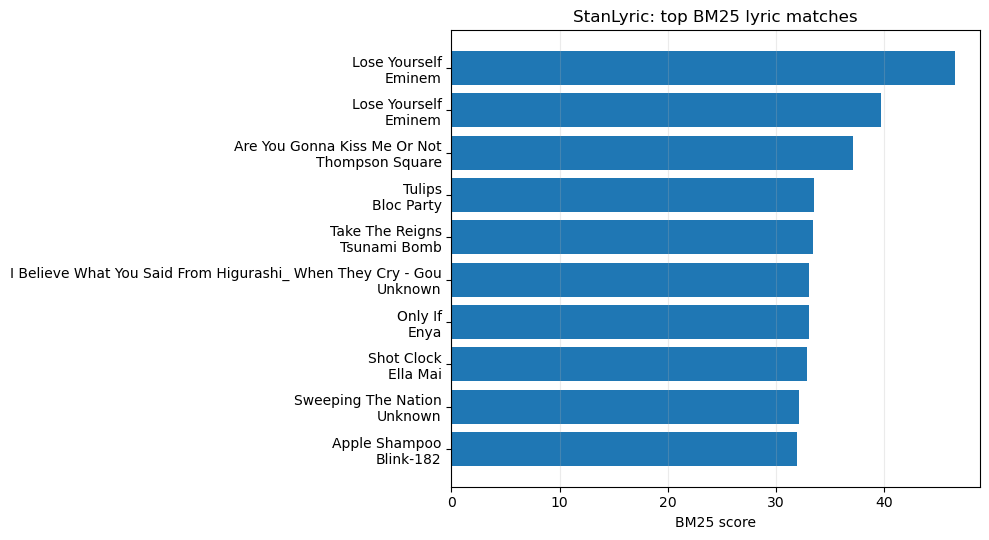

In [10]:
plot_top_scores(results[display_cols], title="StanLyric: top BM25 lyric matches");

## 8. Evaluate BM25 retrieval
We create synthetic queries by sampling lyric fragments from known songs, then measure whether BM25 retrieves the source song.

In [11]:
evaluator = RetrievalEvaluator(engine)
metrics, details, synthetic_queries = evaluator.evaluate_synthetic(
    EvalConfig(n_queries=200, min_query_tokens=5, max_query_tokens=18, top_k=10, random_state=42)
)
metrics

Evaluating retrieval: 100%|██████████| 200/200 [01:30<00:00,  2.21it/s]


,n_queries,hit@1,hit@3,hit@5,hit@10,recall@10,mrr@10,ndcg@10,median_rank_found,miss_rate@10
0,200,0.725,0.845,0.865,0.91,0.91,0.790909,0.81987,1.0,0.09


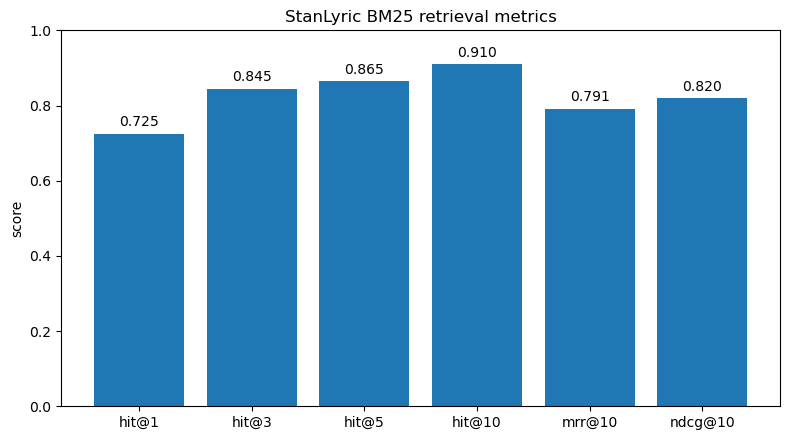

In [12]:
plot_metric_summary(metrics);

In [13]:
details.head(20)

,query,target_doc_id,target_title,target_artist,rank,found_in_top_k,top_prediction,top_artist,top_doc_id,top_score
0,it just isn't fair you listen to their side no...,song_0007870,Shut Up,Madness,1.0,True,Shut Up,Madness,song_0007870,53.273182
1,i'll go back home believe,song_0024279,Prodigal Son [#],The Rolling Stones,1.0,True,Prodigal Son [#],The Rolling Stones,song_0024279,14.017891
2,the boy is bound to roam thought every,song_0001278,Southbound Again,Dire Straits,1.0,True,Southbound Again,Dire Straits,song_0001278,37.660774
3,dogs the hell patrol the hell patrol,song_0019640,Hell Patrol,Judas Priest,1.0,True,Hell Patrol,Judas Priest,song_0019640,63.278145
4,me don't you know it hit,song_0007220,It Hit Me Like A Hammer,Huey Lewis & The News,1.0,True,It Hit Me Like A Hammer,Huey Lewis & The News,song_0007220,23.658613
5,we are above the law let our power show that w...,song_0037996,Let The Hammer Fall,Hammerfall,1.0,True,Let The Hammer Fall,Hammerfall,song_0037996,47.828140
6,since a pirate captain said,song_0012868,Shipwrecked,Alestorm,1.0,True,Shipwrecked,Alestorm,song_0012868,21.961946
7,to the nightmare salute you 'till,song_0040532,March Onward To Your Nightmare,Unknown,1.0,True,March Onward To Your Nightmare,Unknown,song_0040532,39.041245
8,dear underneath the moonlight together well sa...,song_0026139,Seaside Rendezvous,Queen,1.0,True,Seaside Rendezvous,Queen,song_0026139,34.907322
9,i'm waiting for you to open your arms and drow...,song_0040539,It'S All Tears (Drown In This Love),Him,1.0,True,It'S All Tears (Drown In This Love),Him,song_0040539,63.390617


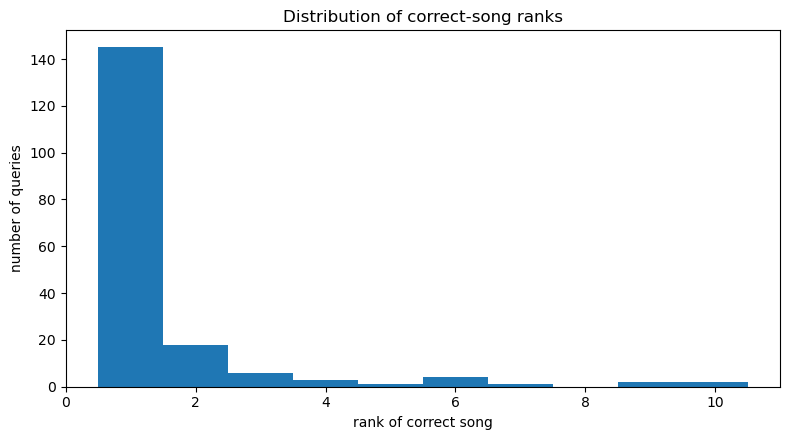

In [14]:
if details["rank"].notna().any():
    plot_rank_distribution(details);

## Next upgrades
1. Add typo/noise robustness queries.
2. Add character n-gram TF-IDF for misremembered lyrics.
3. Add dense embeddings and hybrid BM25 + dense reranking.
4. Connect retrieved songs to Spotify playlist/liked-track metadata.